# Customer Churn Prediction

## Exploratory Data Analysis (EDA)

### Objective
The objective of this project is to analyze customer data, identify churn patterns, understand the factors affecting customer retention, and provide business insights through data visualization.

In [1]:
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Load the dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# Display first 5 rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check number of rows and columns

df.shape

(7043, 21)

In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Statistical summary of numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Check missing values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [10]:
# Display all column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
# Count of Churn and Non-Churn Customers

df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


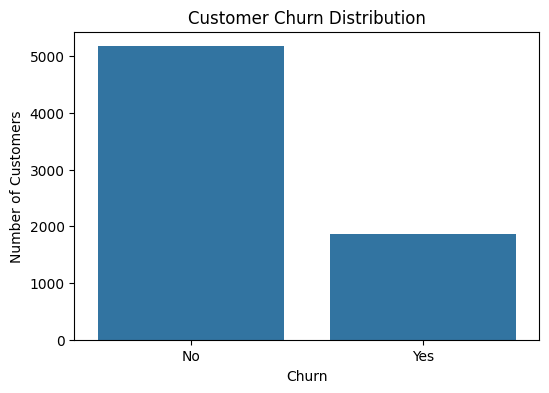

In [12]:
# Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [13]:
# Churn Percentage

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


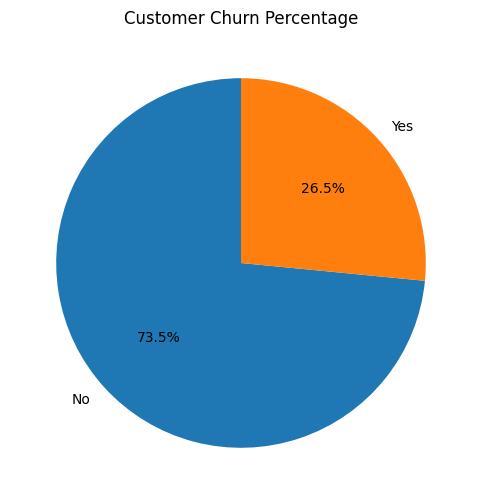

In [14]:
# Pie Chart

plt.figure(figsize=(6,6))

df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.ylabel("")

plt.show()

In [15]:
# Gender Distribution

df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


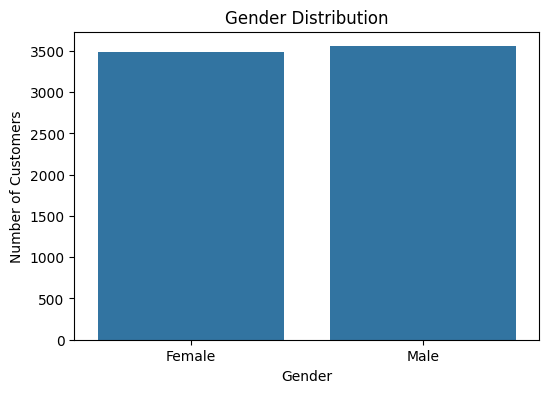

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [17]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


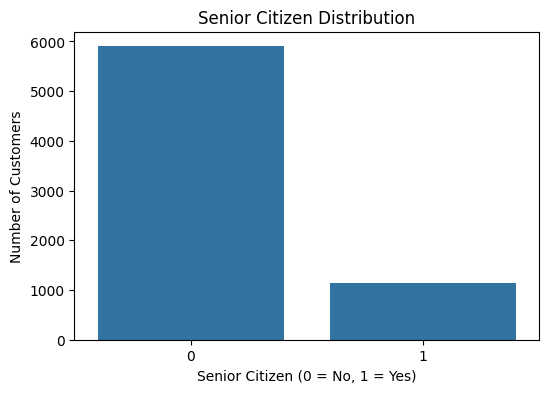

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='SeniorCitizen', data=df)

plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
df['Partner'].value_counts()

,count
Partner,
No,3641
Yes,3402


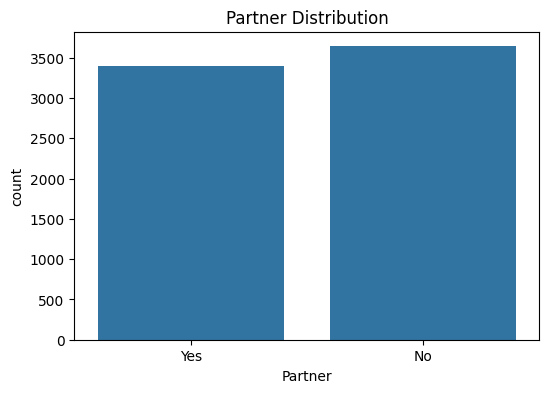

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x='Partner', data=df)

plt.title("Partner Distribution")

plt.show()

In [21]:
df['Dependents'].value_counts()

,count
Dependents,
No,4933
Yes,2110


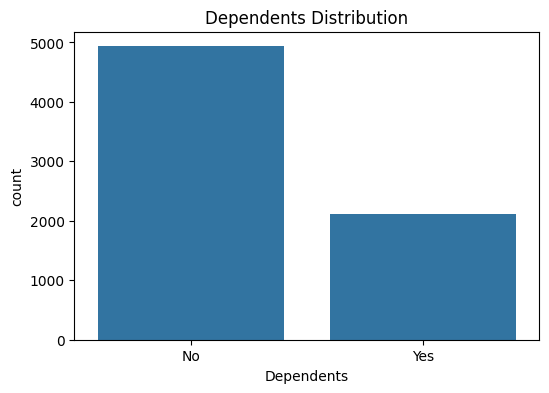

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x='Dependents', data=df)

plt.title("Dependents Distribution")

plt.show()

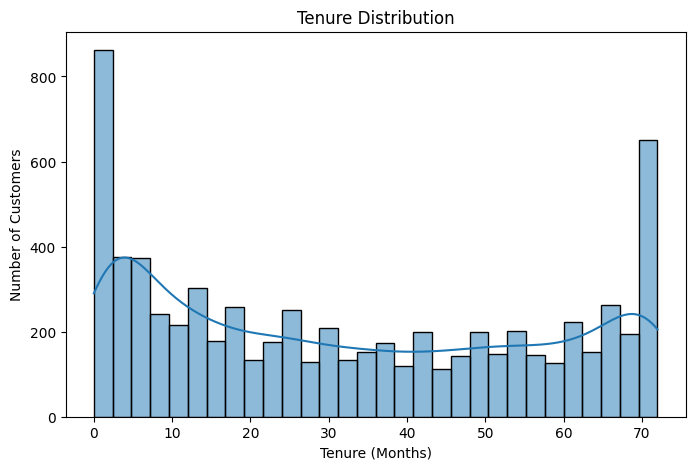

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
df['MonthlyCharges'].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


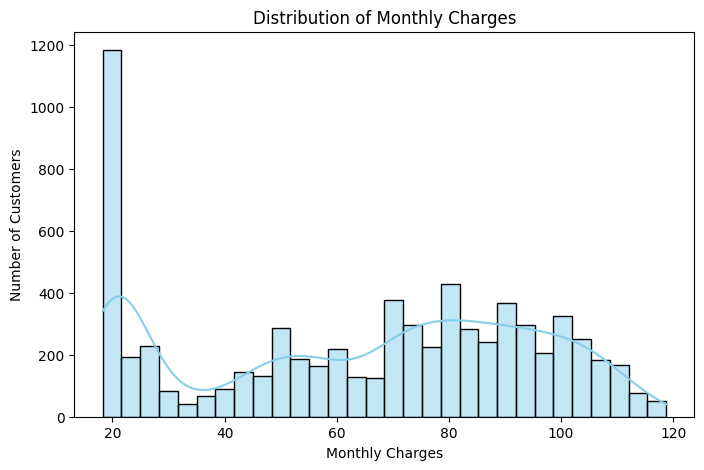

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='skyblue')

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [26]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

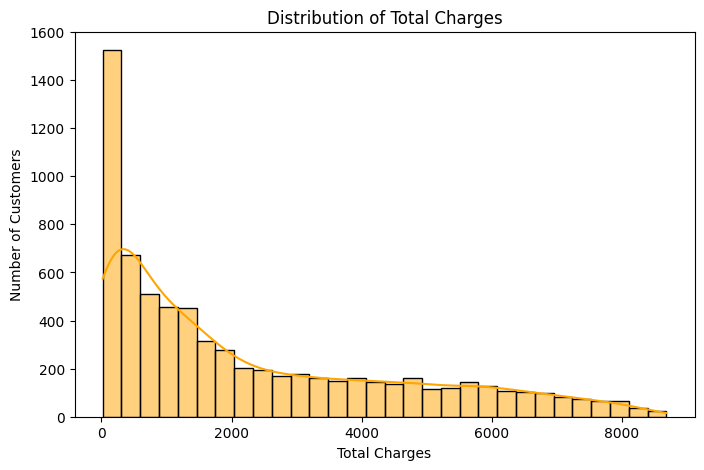

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalCharges'], bins=30, kde=True, color='orange')

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


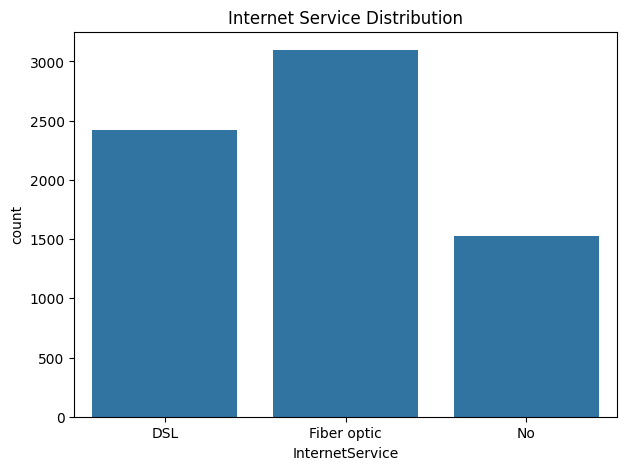

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(x='InternetService', data=df)

plt.title("Internet Service Distribution")

plt.show()

In [30]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


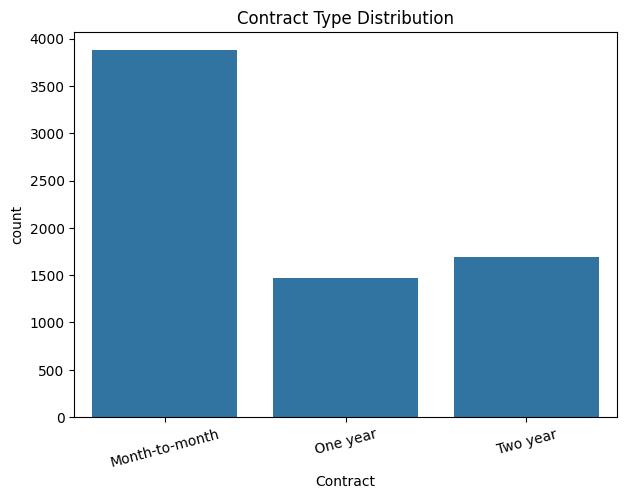

In [31]:
plt.figure(figsize=(7,5))

sns.countplot(x='Contract', data=df)

plt.title("Contract Type Distribution")

plt.xticks(rotation=15)

plt.show()

In [32]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


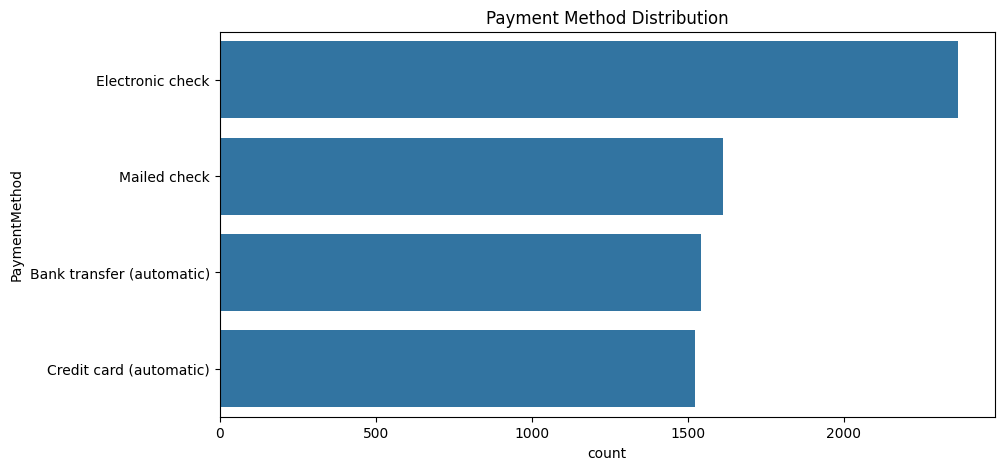

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(y='PaymentMethod', data=df)

plt.title("Payment Method Distribution")

plt.show()

In [34]:
df['PaperlessBilling'].value_counts()

,count
PaperlessBilling,
Yes,4171
No,2872


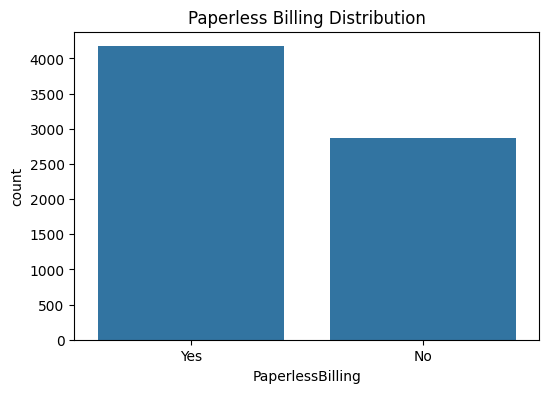

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(x='PaperlessBilling', data=df)

plt.title("Paperless Billing Distribution")

plt.show()

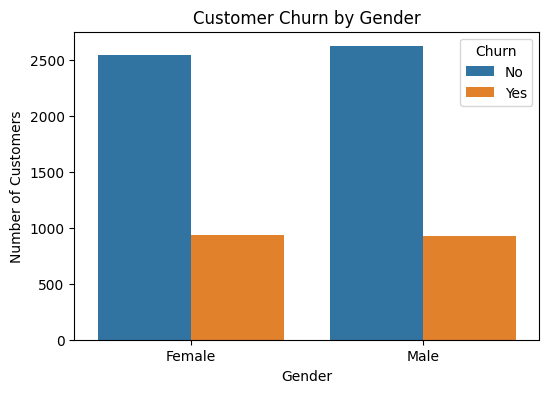

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

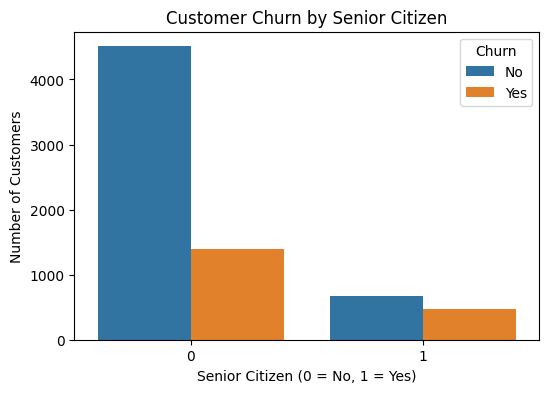

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Customer Churn by Senior Citizen")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

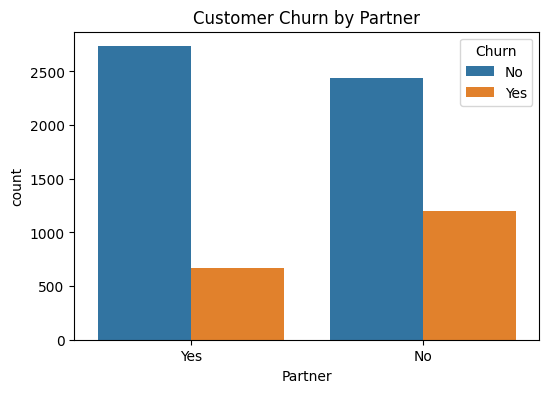

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(x='Partner', hue='Churn', data=df)

plt.title("Customer Churn by Partner")

plt.show()

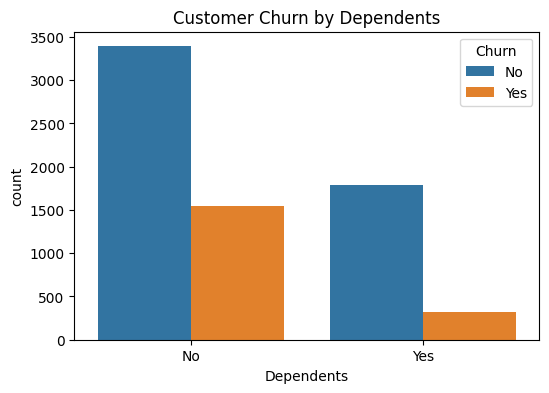

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(x='Dependents', hue='Churn', data=df)

plt.title("Customer Churn by Dependents")

plt.show()

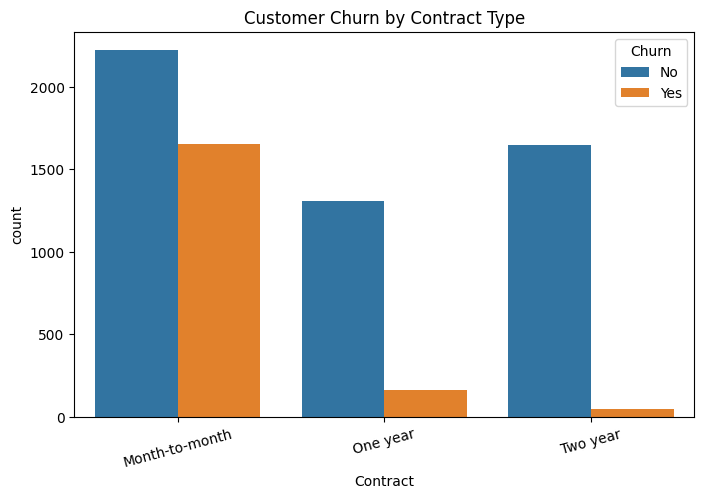

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Customer Churn by Contract Type")

plt.xticks(rotation=15)

plt.show()

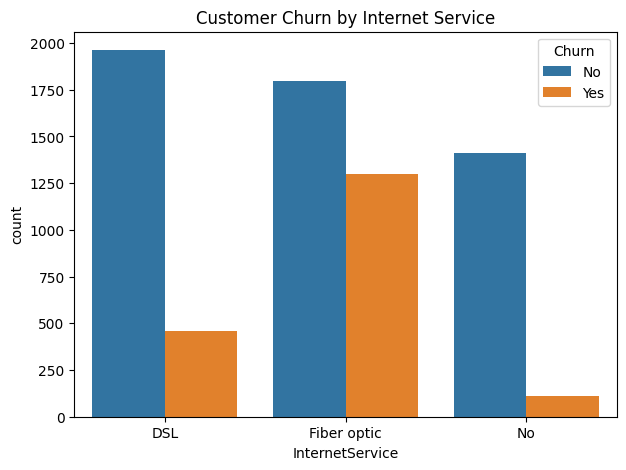

In [41]:
plt.figure(figsize=(7,5))

sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Customer Churn by Internet Service")

plt.show()

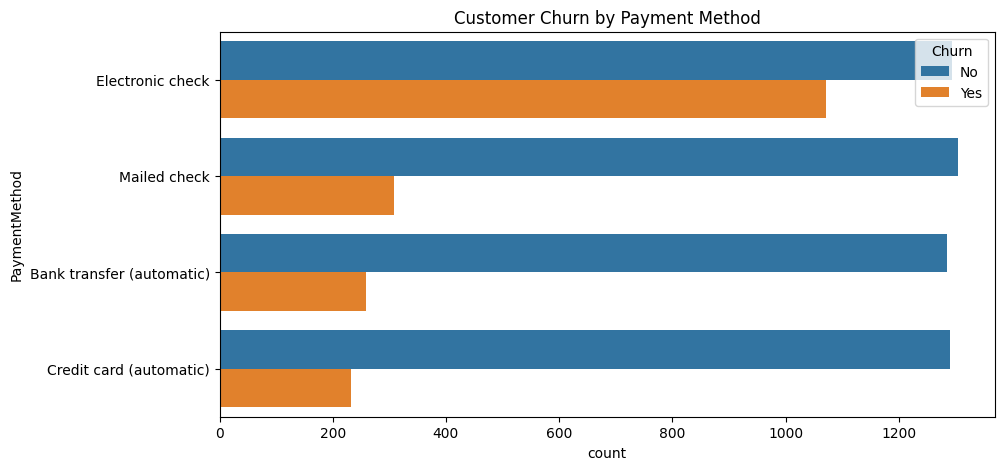

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(y='PaymentMethod', hue='Churn', data=df)

plt.title("Customer Churn by Payment Method")

plt.show()

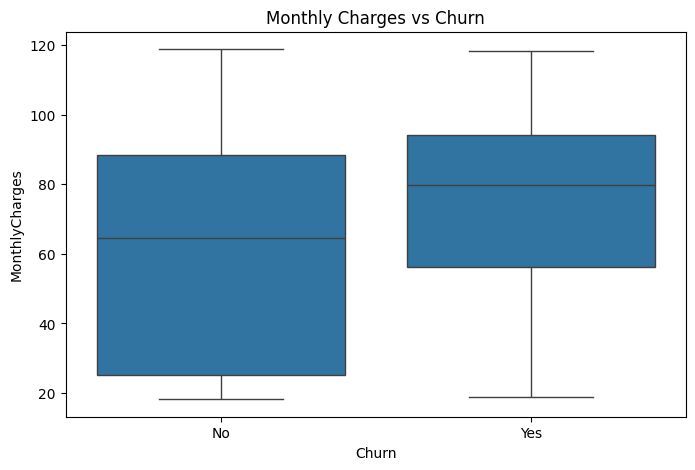

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

In [44]:
# Select numerical columns

numerical_df = df.select_dtypes(include=['int64', 'float64'])

numerical_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [45]:
# Correlation Matrix

corr = numerical_df.corr()

corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


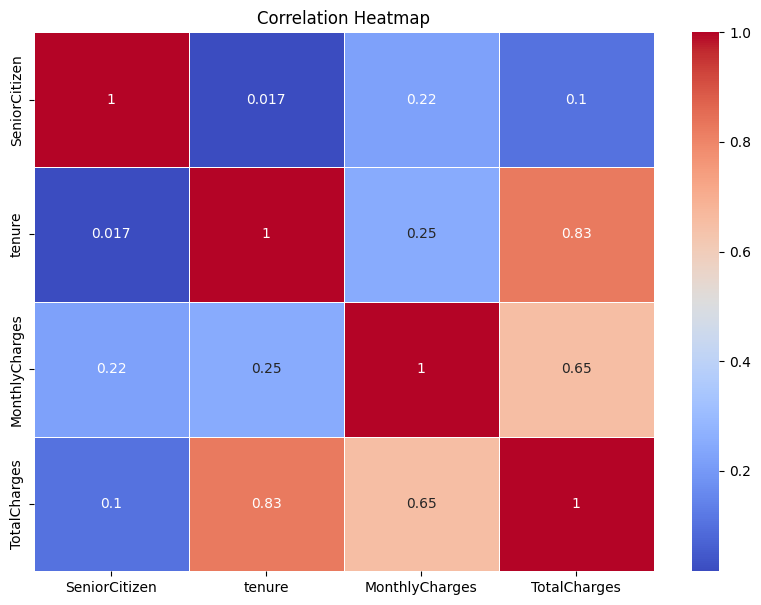

In [46]:
plt.figure(figsize=(10,7))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

In [47]:
fig = px.pie(
    df,
    names='Churn',
    title='Customer Churn Distribution'
)

fig.show()

In [48]:
fig = px.bar(
    df,
    x='Contract',
    color='Churn',
    title='Contract Type vs Churn'
)

fig.show()

In [49]:
fig = px.histogram(
    df,
    x='MonthlyCharges',
    title='Monthly Charges Distribution'
)

fig.show()

In [50]:
fig = px.box(
    df,
    x='Churn',
    y='MonthlyCharges',
    color='Churn',
    title='Monthly Charges by Churn'
)

fig.show()

In [51]:
fig = px.scatter(
    df,
    x='tenure',
    y='MonthlyCharges',
    color='Churn',
    title='Tenure vs Monthly Charges'
)

fig.show()

# Business Insights
1. Churn Distribution

Most customers stay with the company, but a significant number have churned, highlighting the importance of retention strategies.

2. Gender

Male and female customers have similar churn patterns, suggesting that gender is not a major factor influencing churn.

3. Senior Citizen

Senior citizens appear to have a higher churn rate than non-senior customers.

4. Partner

Customers with partners generally show better retention than those without partners.

5. Dependents

Customers with dependents tend to stay longer with the company.

6. Contract Type

Customers on month-to-month contracts have the highest churn rate. Longer contracts are associated with better customer retention.

7. Internet Service

Fiber optic users tend to churn more than DSL users, indicating possible service or pricing issues.

8. Payment Method

Customers using electronic check show higher churn compared to other payment methods.

9. Monthly Charges

Customers with higher monthly charges are more likely to churn.

10. Tenure

Customers with shorter tenure are more likely to leave. Long-term customers are generally more loyal.  

# Data Storytelling

The objective of this analysis was to understand customer churn behavior in a telecom company.

The analysis began by exploring the dataset and understanding the customer demographics and service details. Univariate analysis provided insights into the distribution of individual features such as gender, tenure, contract type, and monthly charges.

Bivariate analysis revealed that contract type, tenure, monthly charges, and internet service have a strong relationship with customer churn.

Customers on month-to-month contracts, with higher monthly charges and shorter tenure, are more likely to leave the company.

Based on these findings, the company should focus on retaining new customers, encouraging long-term contracts, reviewing pricing strategies, and improving customer satisfaction to reduce churn.

# Conclusion

This exploratory data analysis identified the major factors associated with customer churn. Contract type, tenure, monthly charges, and internet service were found to be the most influential features.

The insights generated from this analysis will help the company develop effective customer retention strategies and improve long-term business performance.

This EDA also provides a strong foundation for building machine learning models to predict customer churn in the next phase of the project.